In [43]:
# import libraries

# 1. to handle the data
import pandas as pd
import numpy as np

# 2. To Viusalize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# from yellowbrick.cluster import KElbowVisualizer
from matplotlib.colors import ListedColormap

# 3. To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# 4. import Iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 5. Machine Learning
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score

# 6. For Classification task.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier,RandomForestRegressor
# from xgboost import XGBClassifier

# 7. Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 8. Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [44]:
import pandas as pd

df = pd.read_csv(r"D:\MLDP Project\MLDP-Project---Heart-Disease-Prediction\data\heart_disease_uci.csv")



In [45]:
# Exploring the data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [46]:
# Checking for missing values
df.isnull().sum()


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [47]:
##Renaming the Column Names

df = df.rename(columns={
    "id": "patient_id",
    "age": "age_years",
    "origin": "study_origin",
    "sex": "sex_male_female",
    "cp": "chest_pain_type",
    "trestbps": "resting_bp_mmHg",
    "chol": "serum_cholesterol_mgdl",
    "fbs": "fasting_blood_sugar_gt120",
    "restecg": "resting_ecg_result",
    "thalach": "max_heart_rate",
    "exang": "exercise_induced_angina",
    "oldpeak": "st_depression_exercise",
    "slope": "st_slope_peak_exercise",
    "ca": "num_major_vessels",
    "thal": "thal_defect_type",
    "num": "heart_disease_presence"
})


In [48]:
import pandas as pd

# Example mapping: adjust labels to your clinical definitions
severity_map = {
    0: "Normal",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Very Severe"
}

# Apply mapping
df["severity_label"] = df["heart_disease_presence"].map(severity_map)

# Check the mapping
print(df[["heart_disease_presence", "severity_label"]].head(10))


   heart_disease_presence severity_label
0                       0         Normal
1                       2       Moderate
2                       1           Mild
3                       0         Normal
4                       0         Normal
5                       0         Normal
6                       3         Severe
7                       0         Normal
8                       2       Moderate
9                       1           Mild


In [49]:
df

,patient_id,age_years,sex_male_female,dataset,chest_pain_type,resting_bp_mmHg,serum_cholesterol_mgdl,fasting_blood_sugar_gt120,resting_ecg_result,thalch,exercise_induced_angina,st_depression_exercise,st_slope_peak_exercise,num_major_vessels,thal_defect_type,heart_disease_presence,severity_label
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,Normal
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,Moderate
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,Mild
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,Normal
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1,Mild
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0,Normal
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2,Moderate
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,Normal


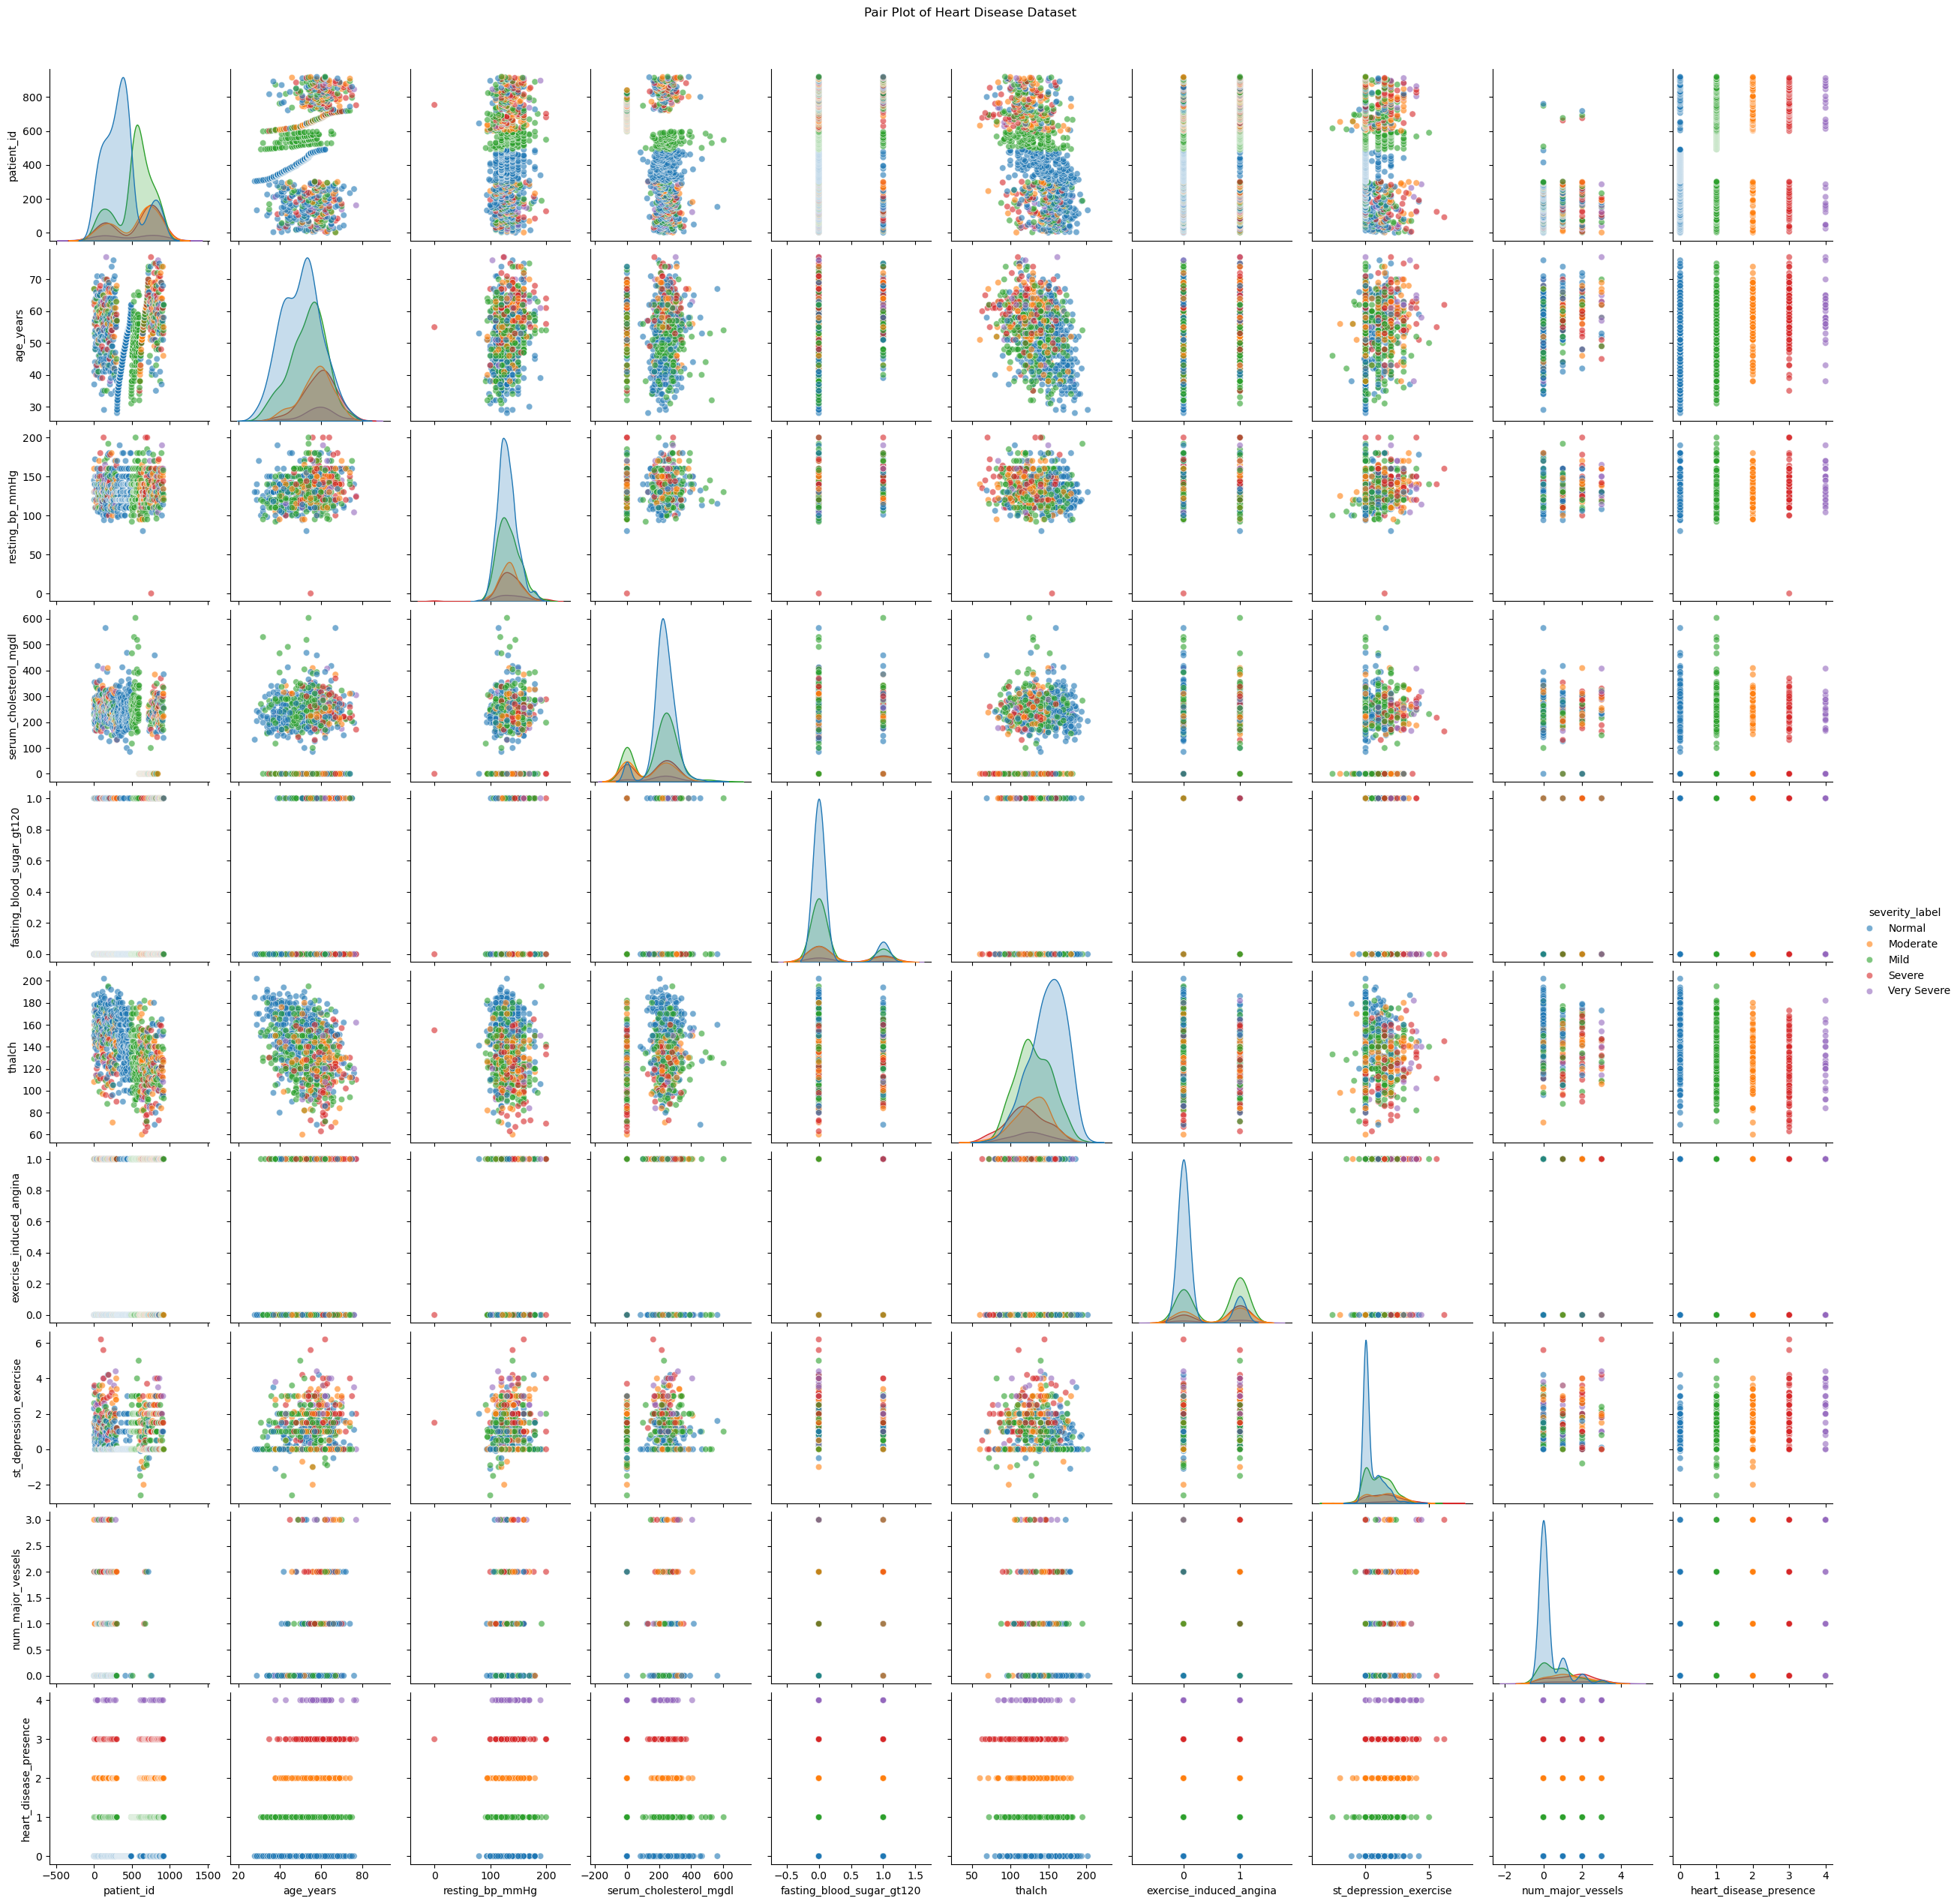

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# I have already created severity_label (Normal vs Very Severe)
hue_col = "severity_label" if "severity_label" in df.columns else "num"

# Create pair plot
sns.pairplot(df, hue=hue_col, diag_kind="kde", plot_kws={"alpha":0.6})
plt.suptitle("Pair Plot of Heart Disease Dataset", y=1.02)
plt.show()


In [51]:
#Dropping ID Column to avoid any confusion in model training

df = df.drop(columns=["patient_id", "dataset"])
## predicting severity of Heart Disease

In [52]:
df

,age_years,sex_male_female,chest_pain_type,resting_bp_mmHg,serum_cholesterol_mgdl,fasting_blood_sugar_gt120,resting_ecg_result,thalch,exercise_induced_angina,st_depression_exercise,st_slope_peak_exercise,num_major_vessels,thal_defect_type,heart_disease_presence,severity_label
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,Normal
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,Moderate
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,Mild
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,Normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1,Mild
916,62,Male,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0,Normal
917,55,Male,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2,Moderate
918,58,Male,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,Normal


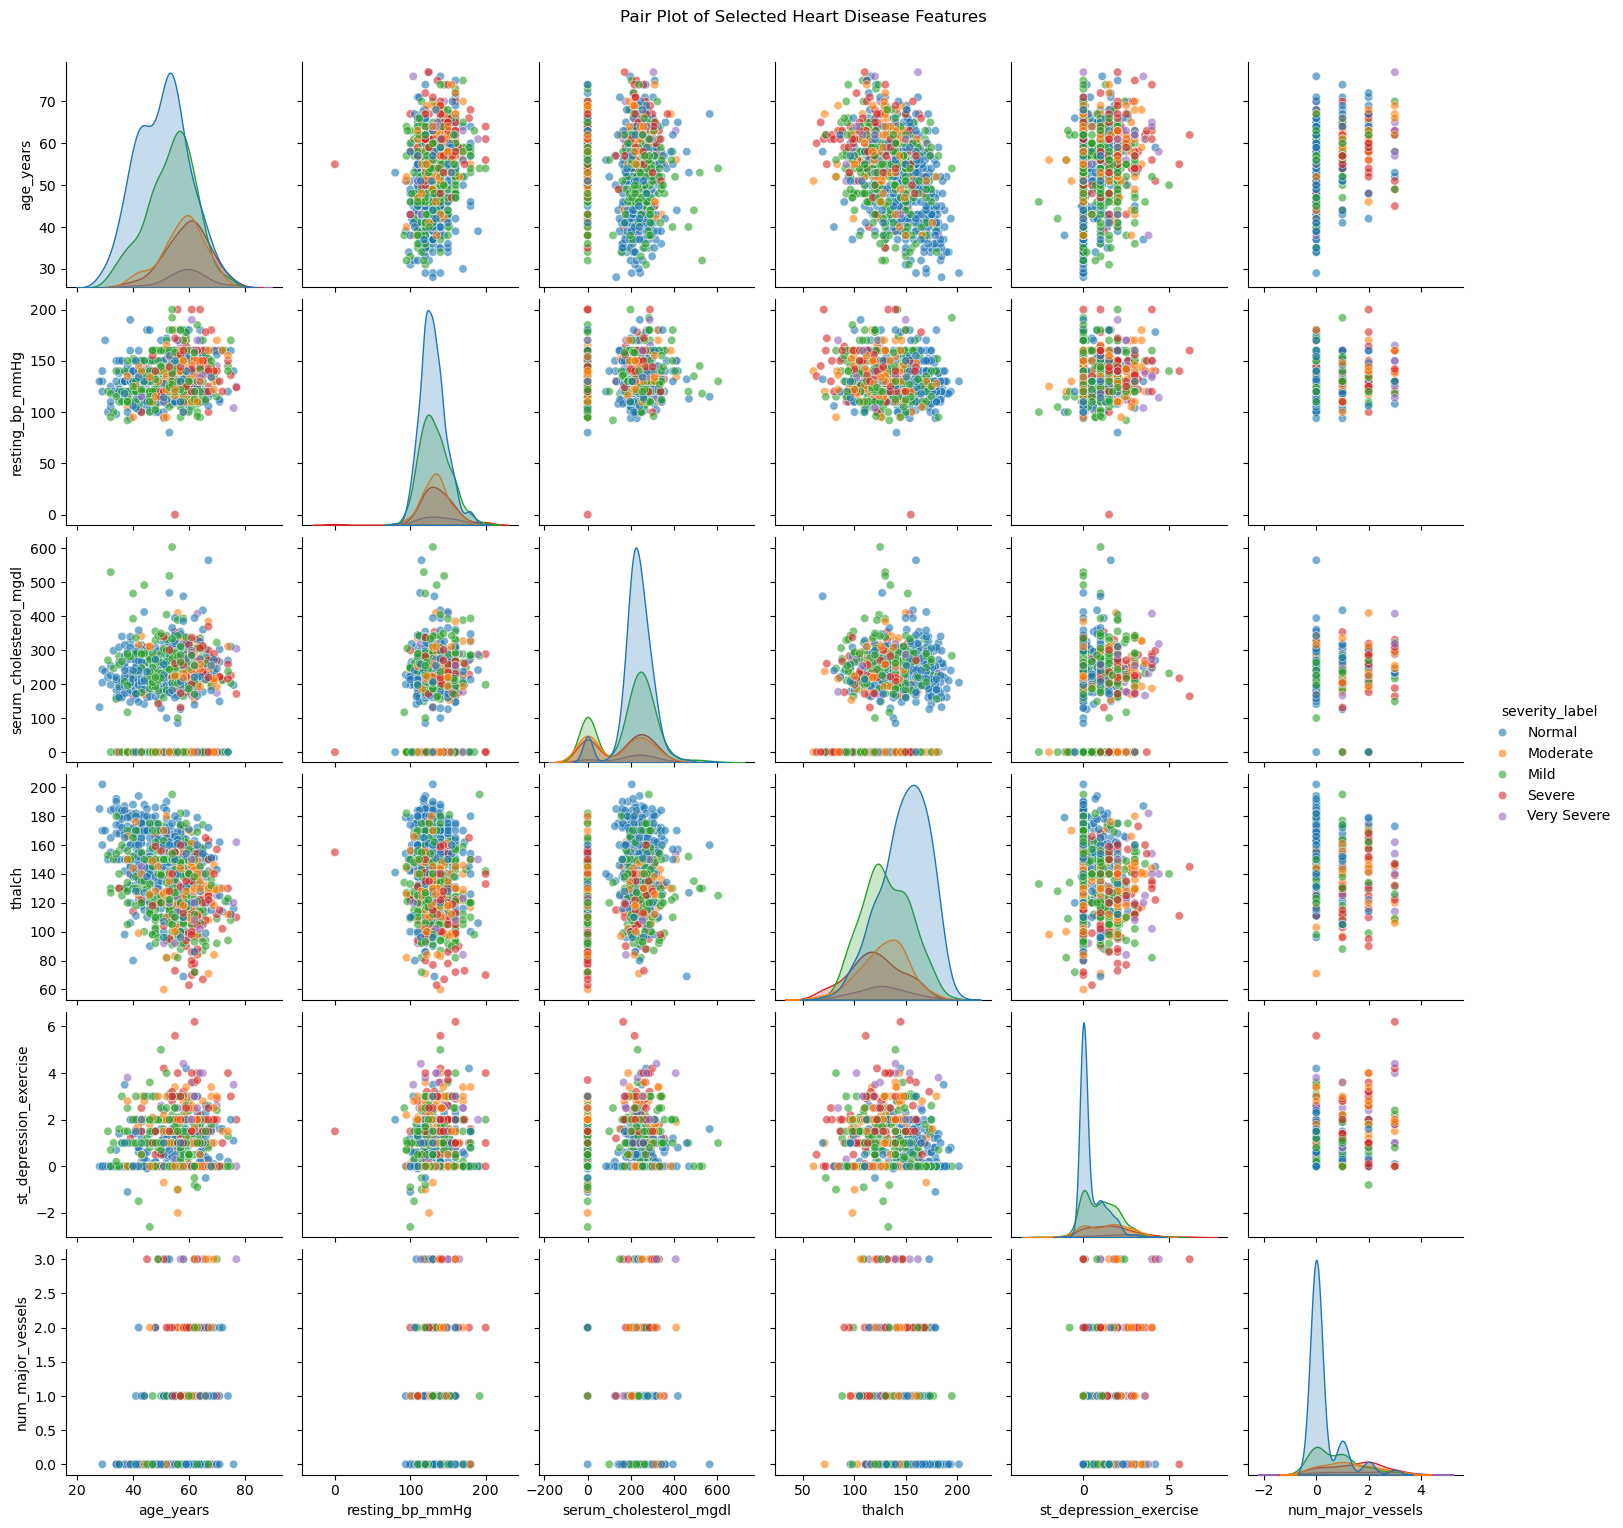

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chosen the target column for coloring
hue_col = "severity_label" if "severity_label" in df.columns else "heart_disease_presence"

# Selected only the numeric predictors + target column
plot_cols = ["age_years", "resting_bp_mmHg", "serum_cholesterol_mgdl",
             "thalch", "st_depression_exercise", "num_major_vessels"]

plot_df = df[plot_cols + [hue_col]]

# Create pair plot
sns.pairplot(plot_df,
             hue=hue_col,
             diag_kind="kde",
             plot_kws={"alpha":0.6})

plt.suptitle("Pair Plot of Selected Heart Disease Features", y=1.02)  
plt.show()


In [54]:
#Dropping missing values

# Drop rows with any missing values
df = df.dropna()

# Drop columns with too many missing values
df = df.dropna(axis=1)


In [55]:
# Check how many missing values per column
print(df.isnull().sum())

# Check if any missing values exist
print(df.isnull().any())

#Cleaned and Removed Missing Values

# Checking the data shape
df.shape

#299 Rows and 13 columns

age_years                    0
sex_male_female              0
chest_pain_type              0
resting_bp_mmHg              0
serum_cholesterol_mgdl       0
fasting_blood_sugar_gt120    0
resting_ecg_result           0
thalch                       0
exercise_induced_angina      0
st_depression_exercise       0
st_slope_peak_exercise       0
num_major_vessels            0
thal_defect_type             0
heart_disease_presence       0
severity_label               0
dtype: int64
age_years                    False
sex_male_female              False
chest_pain_type              False
resting_bp_mmHg              False
serum_cholesterol_mgdl       False
fasting_blood_sugar_gt120    False
resting_ecg_result           False
thalch                       False
exercise_induced_angina      False
st_depression_exercise       False
st_slope_peak_exercise       False
num_major_vessels            False
thal_defect_type             False
heart_disease_presence       False
severity_label               Fal

(299, 15)

In [56]:
df.max()


age_years                                   77
sex_male_female                           Male
chest_pain_type                 typical angina
resting_bp_mmHg                          200.0
serum_cholesterol_mgdl                   564.0
fasting_blood_sugar_gt120                 True
resting_ecg_result            st-t abnormality
thalch                                   202.0
exercise_induced_angina                   True
st_depression_exercise                     6.2
st_slope_peak_exercise               upsloping
num_major_vessels                          3.0
thal_defect_type             reversable defect
heart_disease_presence                       4
severity_label                     Very Severe
dtype: object

In [57]:
df.min()

age_years                                29
sex_male_female                      Female
chest_pain_type                asymptomatic
resting_bp_mmHg                        94.0
serum_cholesterol_mgdl                100.0
fasting_blood_sugar_gt120             False
resting_ecg_result           lv hypertrophy
thalch                                 71.0
exercise_induced_angina               False
st_depression_exercise                  0.0
st_slope_peak_exercise          downsloping
num_major_vessels                       0.0
thal_defect_type               fixed defect
heart_disease_presence                    0
severity_label                         Mild
dtype: object

In [58]:
#showing unique values

df.nunique()

age_years                     41
sex_male_female                2
chest_pain_type                4
resting_bp_mmHg               50
serum_cholesterol_mgdl       153
fasting_blood_sugar_gt120      2
resting_ecg_result             3
thalch                        92
exercise_induced_angina        2
st_depression_exercise        40
st_slope_peak_exercise         3
num_major_vessels              4
thal_defect_type               3
heart_disease_presence         5
severity_label                 5
dtype: int64

In [59]:
import pandas as pd

# Example: assume df is my DataFrame
# Map values 0–4 to severity labels
severity_map = {
    0: "Normal",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Very Severe"
}

df["severity_label"] = df["heart_disease_presence"].map(severity_map)

# Check the mapping
print(df[["heart_disease_presence", "severity_label"]].head(10))


   heart_disease_presence severity_label
0                       0         Normal
1                       2       Moderate
2                       1           Mild
3                       0         Normal
4                       0         Normal
5                       0         Normal
6                       3         Severe
7                       0         Normal
8                       2       Moderate
9                       1           Mild


In [60]:
df

,age_years,sex_male_female,chest_pain_type,resting_bp_mmHg,serum_cholesterol_mgdl,fasting_blood_sugar_gt120,resting_ecg_result,thalch,exercise_induced_angina,st_depression_exercise,st_slope_peak_exercise,num_major_vessels,thal_defect_type,heart_disease_presence,severity_label
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,Normal
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,Moderate
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,Mild
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,Normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,68,Male,asymptomatic,144.0,193.0,True,normal,141.0,False,3.4,flat,2.0,reversable defect,2,Moderate
300,57,Male,asymptomatic,130.0,131.0,False,normal,115.0,True,1.2,flat,1.0,reversable defect,3,Severe
301,57,Female,atypical angina,130.0,236.0,False,lv hypertrophy,174.0,False,0.0,flat,1.0,normal,1,Mild
508,47,Male,asymptomatic,150.0,226.0,False,normal,98.0,True,1.5,flat,0.0,reversable defect,1,Mild


In [61]:
df = df.drop(columns=["heart_disease_presence"])


In [62]:
df

,age_years,sex_male_female,chest_pain_type,resting_bp_mmHg,serum_cholesterol_mgdl,fasting_blood_sugar_gt120,resting_ecg_result,thalch,exercise_induced_angina,st_depression_exercise,st_slope_peak_exercise,num_major_vessels,thal_defect_type,severity_label
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,Normal
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,Moderate
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,Mild
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,Normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,68,Male,asymptomatic,144.0,193.0,True,normal,141.0,False,3.4,flat,2.0,reversable defect,Moderate
300,57,Male,asymptomatic,130.0,131.0,False,normal,115.0,True,1.2,flat,1.0,reversable defect,Severe
301,57,Female,atypical angina,130.0,236.0,False,lv hypertrophy,174.0,False,0.0,flat,1.0,normal,Mild
508,47,Male,asymptomatic,150.0,226.0,False,normal,98.0,True,1.5,flat,0.0,reversable defect,Mild


In [63]:
# Save the cleaned DataFrame to a new Excel File


df.to_excel(r"D:\MLDP Project\data\heart_disease_clean.xlsx", index=False)